# Card Detection Test

Pick one image from `train_images`, detect candidate cards, and display the extracted crops.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "iapr-26-uno-vision-challenge"
TRAIN_DIR = DATASET_DIR / "train_images"
COLORS = ("blue", "red", "yellow", "black", "green")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
HSV_ARRAY_PATTERN = re.compile(r"np\.array\(\s*\[([^\]]+)\]\s*\)")
KEY_VALUE_PATTERN = re.compile(r"^\s*([^:]+)\s*:\s*(\d+)\s*$", re.MULTILINE)
SCALE = 0.25
THRESHOLD_RECTANGLE_SETTINGS_PATH = BASE_DIR / "threshold_rectangle_set.txt"
CARD_TEMPLATE_MASK_PATH = BASE_DIR / "general_card_mask.png"
RECTANGLE_SETTINGS_PATH = BASE_DIR / "hough_set.txt"

# Change this to test another training image.
IMAGE_NAME = "L1000983.jpg"


In [ ]:
def train_images() -> list[Path]:
    return [path for path in sorted(TRAIN_DIR.iterdir()) if path.suffix.lower() in IMAGE_EXTENSIONS]


def parse_hsv_file(path: Path) -> list[tuple[np.ndarray, np.ndarray]]:
    arrays = []
    for match in HSV_ARRAY_PATTERN.finditer(path.read_text(encoding="utf-8")):
        values = [int(value.strip()) for value in match.group(1).split(",")]
        arrays.append(np.array(values, dtype=np.uint8))
    if len(arrays) % 2 != 0 or not arrays:
        raise ValueError(f"Expected lower/upper HSV pairs in {path}")
    return list(zip(arrays[0::2], arrays[1::2]))


def threshold_hsv_image(image_bgr: np.ndarray, ranges: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lower, upper))
    return mask


def load_color_thresholds() -> dict[str, dict]:
    thresholds = {}
    for color in COLORS:
        if color == "black":
            thresholds[color] = {"mode": "gray", "settings": load_gray_threshold(BASE_DIR / "black_gray.txt")}
        else:
            thresholds[color] = {"mode": "hsv", "ranges": parse_hsv_file(BASE_DIR / f"{color}_hsv.txt")}
    return thresholds


def save_hsv_thresholds(path: Path, ranges: list[tuple[np.ndarray, np.ndarray]]) -> None:
    lines = []
    for index, (lower, upper) in enumerate(ranges, start=1):
        suffix = f"_{index}" if len(ranges) > 1 else ""
        lower_values = ", ".join(str(int(value)) for value in lower)
        upper_values = ", ".join(str(int(value)) for value in upper)
        lines.append(f"lower_hsv{suffix} = np.array([{lower_values}])")
        lines.append(f"upper_hsv{suffix} = np.array([{upper_values}])")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def load_gray_threshold(path: Path) -> dict[str, int]:
    defaults = {"low": 0, "high": 100}
    if not path.exists():
        return defaults
    parsed = {key.strip().lower().replace(" ", "_"): int(value) for key, value in KEY_VALUE_PATTERN.findall(path.read_text(encoding="utf-8"))}
    defaults.update({key: parsed[key] for key in defaults if key in parsed})
    return defaults


def save_gray_threshold(path: Path, settings: dict[str, int]) -> None:
    path.write_text(f"Low: {settings['low']}\nHigh: {settings['high']}\n", encoding="utf-8")


def threshold_gray_image(image_bgr: np.ndarray, low: int, high: int) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    low, high = sorted((int(low), int(high)))
    return cv2.inRange(gray, low, high)


def load_rectangle_settings(path: Path) -> dict[str, int]:
    defaults = {"min_fill": 35, "min_score": 0, "angle_step": 10, "max_outside": 100}
    if not path.exists():
        return defaults
    parsed = {key.strip().lower().replace(" ", "_"): int(value) for key, value in KEY_VALUE_PATTERN.findall(path.read_text(encoding="utf-8"))}
    for key in ("min_fill", "min_score", "angle_step", "max_outside"):
        if key in parsed:
            defaults[key] = parsed[key]
    return defaults


def load_threshold_rectangle_settings(path: Path, rectangle_defaults: dict[str, int]) -> dict[str, int]:
    defaults = {
        "min_area": 0,
        "close_size": 5,
        "close_iter": 1,
        **rectangle_defaults,
    }
    if not path.exists():
        return defaults
    parsed = {key.strip().lower().replace(" ", "_"): int(value) for key, value in KEY_VALUE_PATTERN.findall(path.read_text(encoding="utf-8"))}
    defaults.update({key: parsed[key] for key in defaults if key in parsed})
    return defaults


def save_threshold_rectangle_settings(path: Path, settings: dict[str, int]) -> None:
    path.write_text(
        f"Min area: {settings['min_area']}\n"
        f"Close size: {settings['close_size']}\n"
        f"Close iter: {settings['close_iter']}\n"
        f"Min fill: {settings['min_fill']}\n"
        f"Min score: {settings['min_score']}\n"
        f"Angle step: {settings['angle_step']}\n"
        f"Max outside: {settings['max_outside']}\n",
        encoding="utf-8",
    )


def close_mask(mask: np.ndarray, close_size: int, close_iter: int) -> np.ndarray:
    if close_size <= 0 or close_iter <= 0:
        return mask.copy()
    if close_size % 2 == 0:
        close_size += 1
    kernel = np.ones((close_size, close_size), dtype=np.uint8)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=close_iter)


def filter_small_components(mask: np.ndarray, min_area: int) -> np.ndarray:
    if min_area <= 0:
        return mask.copy()
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    filtered = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == label] = 255
    return filtered


def threshold_color_image(image_bgr: np.ndarray, threshold: dict) -> np.ndarray:
    if threshold["mode"] == "gray":
        settings = threshold["settings"]
        return threshold_gray_image(image_bgr, settings["low"], settings["high"])
    return threshold_hsv_image(image_bgr, threshold["ranges"])


def build_threshold_mask(mask: np.ndarray, settings: dict[str, int]) -> np.ndarray:
    area_mask = filter_small_components(mask, settings["min_area"])
    return close_mask(area_mask, settings["close_size"], settings["close_iter"])


In [ ]:
def bbox_iou(box_a: tuple[int, int, int, int], box_b: tuple[int, int, int, int]) -> float:
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    x1 = max(ax, bx)
    y1 = max(ay, by)
    x2 = min(ax + aw, bx + bw)
    y2 = min(ay + ah, by + bh)
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    union = aw * ah + bw * bh - intersection
    return intersection / union if union > 0 else 0.0


def rotate_template(template_mask: np.ndarray, angle_degrees: float) -> tuple[np.ndarray, np.ndarray]:
    height, width = template_mask.shape[:2]
    center = (width / 2.0, height / 2.0)
    transform = cv2.getRotationMatrix2D(center, angle_degrees, 1.0)
    cos_t = abs(transform[0, 0])
    sin_t = abs(transform[0, 1])
    rotated_width = int(round(height * sin_t + width * cos_t))
    rotated_height = int(round(height * cos_t + width * sin_t))
    transform[0, 2] += rotated_width / 2.0 - center[0]
    transform[1, 2] += rotated_height / 2.0 - center[1]
    rotated = cv2.warpAffine(template_mask, transform, (rotated_width, rotated_height), flags=cv2.INTER_NEAREST)
    source_corners = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype=np.float32)
    rotated_corners = cv2.transform(source_corners.reshape(1, -1, 2), transform).reshape(-1, 2).astype(np.float32)
    return cv2.threshold(rotated, 127, 255, cv2.THRESH_BINARY)[1], rotated_corners


def prepare_template_mask(template_mask: np.ndarray) -> np.ndarray:
    return cv2.threshold(template_mask, 127, 255, cv2.THRESH_BINARY)[1]


def candidate_from_template(component_mask: np.ndarray, rotated_template: np.ndarray, rotated_corners: np.ndarray, top_left: tuple[int, int]):
    x, y = top_left
    template_height, template_width = rotated_template.shape[:2]
    if x < 0 or y < 0 or x + template_width > component_mask.shape[1] or y + template_height > component_mask.shape[0]:
        return None
    roi = component_mask[y:y + template_height, x:x + template_width]
    template_area = max(1, int(np.count_nonzero(rotated_template)))
    overlap = int(np.count_nonzero(cv2.bitwise_and(roi, rotated_template)))
    fit_ratio = overlap / template_area
    placed_corners = rotated_corners + np.array([x, y], dtype=np.float32)
    box = placed_corners.reshape(-1, 1, 2)
    bx, by, bw, bh = cv2.boundingRect(box.astype(np.int32))
    placed_template = np.zeros_like(component_mask)
    placed_template[y:y + template_height, x:x + template_width] = rotated_template
    score = overlap * fit_ratio
    return score, box, (bx, by, bw, bh), (template_width, template_height), fit_ratio, placed_template


def warp_template_to_box(template_mask: np.ndarray, box: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    height, width = template_mask.shape[:2]
    source = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype=np.float32)
    destination = box.reshape(-1, 2).astype(np.float32)
    transform = cv2.getPerspectiveTransform(source, destination)
    warped = cv2.warpPerspective(template_mask, transform, (shape[1], shape[0]), flags=cv2.INTER_NEAREST)
    return cv2.threshold(warped, 127, 255, cv2.THRESH_BINARY)[1]


def remove_confirmed_candidate(mask: np.ndarray, candidate) -> np.ndarray:
    remaining = mask.copy()
    box_int = candidate[1].astype(np.int32).reshape(-1, 1, 2)
    cv2.fillConvexPoly(remaining, box_int, 0)
    return remaining


def outside_rectangle_ratio(mask: np.ndarray, box: np.ndarray) -> float:
    rectangle_mask = np.zeros_like(mask)
    box_int = box.astype(np.int32).reshape(-1, 1, 2)
    cv2.fillConvexPoly(rectangle_mask, box_int, 255)
    num_labels, labels, _, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return 0.0
    overlapping_labels = np.unique(labels[(rectangle_mask > 0) & (labels > 0)])
    if overlapping_labels.size == 0:
        return 0.0
    blob_mask = np.isin(labels, overlapping_labels)
    total_pixels = int(np.count_nonzero(blob_mask))
    outside_pixels = int(np.count_nonzero(blob_mask & (rectangle_mask == 0)))
    return outside_pixels / total_pixels if total_pixels > 0 else 0.0


def best_template_candidate(component_mask: np.ndarray, template_mask: np.ndarray, min_fill: float, max_outside: float, angles: range):
    if np.count_nonzero(component_mask) == 0:
        return None
    best = None
    for angle in angles:
        rotated_template, rotated_corners = rotate_template(template_mask, angle)
        th, tw = rotated_template.shape[:2]
        if th > component_mask.shape[0] or tw > component_mask.shape[1]:
            continue
        response = cv2.matchTemplate(component_mask, rotated_template, cv2.TM_CCORR)
        if response.size == 0:
            continue
        template_area = max(1, int(np.count_nonzero(rotated_template)))
        response = response / (255.0 * 255.0 * template_area)
        response = np.nan_to_num(response, nan=0.0, posinf=0.0, neginf=0.0)
        _, max_value, _, max_location = cv2.minMaxLoc(response)
        if max_value < min_fill:
            continue
        candidate = candidate_from_template(component_mask, rotated_template, rotated_corners, max_location)
        if candidate is None or candidate[4] < min_fill:
            continue
        outside_ratio = outside_rectangle_ratio(component_mask, candidate[1])
        if outside_ratio > max_outside:
            continue
        if best is None or candidate[0] > best[0]:
            best = candidate
    return best


def fit_card_mask_candidates(mask: np.ndarray, settings: dict[str, int], card_template_mask: np.ndarray, return_debug: bool = False):
    template_mask = prepare_template_mask(card_template_mask)
    min_fill = settings["min_fill"] / 100.0
    max_outside = settings.get("max_outside", 100) / 100.0
    min_score = float(settings.get("min_score", 0))
    angle_step = max(1, int(settings.get("angle_step", 10)))
    angles = range(-90, 91, angle_step)
    remaining_mask = mask.copy()
    candidates = []

    while True:
        candidate = best_template_candidate(remaining_mask, template_mask, min_fill, max_outside, angles)
        if candidate is None or candidate[0] < min_score:
            break
        before_pixels = int(np.count_nonzero(remaining_mask))
        candidates.append(candidate)
        remaining_mask = remove_confirmed_candidate(remaining_mask, candidate)
        after_pixels = int(np.count_nonzero(remaining_mask))
        if after_pixels >= before_pixels:
            break

    if return_debug:
        return candidates, remaining_mask, candidates.copy()
    return candidates


def detect_rectangles(mask: np.ndarray, settings: dict[str, int], card_template_mask: np.ndarray):
    small_mask = cv2.resize(mask, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    candidates = fit_card_mask_candidates(small_mask, settings, card_template_mask)
    return small_mask, candidates


In [ ]:
def order_box_points(points: np.ndarray) -> np.ndarray:
    points = np.array(points, dtype=np.float32).reshape(-1, 2)
    if len(points) != 4:
        raise ValueError(f"Expected 4 box points, got shape {points.shape}")
    sums = points.sum(axis=1)
    diffs = np.diff(points, axis=1).ravel()
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = points[np.argmin(sums)]
    ordered[2] = points[np.argmax(sums)]
    ordered[1] = points[np.argmin(diffs)]
    ordered[3] = points[np.argmax(diffs)]
    return ordered


def extract_rotated_rectangle(image_bgr: np.ndarray, box_small: np.ndarray, scale: float = SCALE) -> np.ndarray:
    ordered = order_box_points(box_small / scale)
    width = max(1, int(round(max(np.linalg.norm(ordered[2] - ordered[3]), np.linalg.norm(ordered[1] - ordered[0])))))
    height = max(1, int(round(max(np.linalg.norm(ordered[1] - ordered[2]), np.linalg.norm(ordered[0] - ordered[3])))))
    destination = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype=np.float32)
    transform = cv2.getPerspectiveTransform(ordered, destination)
    return cv2.warpPerspective(image_bgr, transform, (width, height))


def extract_card_with_white_background(image_bgr: np.ndarray, box_small: np.ndarray, placed_template_small: np.ndarray) -> np.ndarray:
    full_template = cv2.resize(placed_template_small, (image_bgr.shape[1], image_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)
    extracted = extract_rotated_rectangle(image_bgr, box_small)
    extracted_mask = extract_rotated_rectangle(full_template, box_small)
    extracted_mask = cv2.threshold(extracted_mask, 127, 255, cv2.THRESH_BINARY)[1]
    cleaned = np.full_like(extracted, 255)
    cleaned[extracted_mask > 0] = extracted[extracted_mask > 0]
    return cleaned


def paint_detected_rectangle_white(image_bgr: np.ndarray, box_small: np.ndarray, scale: float = SCALE) -> None:
    box_full = (box_small / scale).astype(np.int32).reshape(-1, 1, 2)
    cv2.fillConvexPoly(image_bgr, box_full, (255, 255, 255))


def show_images(images: list[tuple[str, np.ndarray]], cols: int = 3, figsize: tuple[int, int] = (14, 10)) -> None:
    if not images:
        print("No images to show")
        return
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, (title, image) in zip(axes, images):
        ax.imshow(image if image.ndim == 3 else image, cmap=None if image.ndim == 3 else "gray")
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
color_thresholds = load_color_thresholds()
rectangle_defaults = load_rectangle_settings(RECTANGLE_SETTINGS_PATH)
threshold_rectangle_settings = load_threshold_rectangle_settings(THRESHOLD_RECTANGLE_SETTINGS_PATH, rectangle_defaults)

image_path = TRAIN_DIR / IMAGE_NAME
if not image_path.exists():
    available = train_images()
    if not available:
        raise FileNotFoundError(f"No training images found in {TRAIN_DIR}")
    image_path = available[0]

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
card_template_mask = cv2.imread(str(CARD_TEMPLATE_MASK_PATH), cv2.IMREAD_GRAYSCALE)
if card_template_mask is None:
    raise FileNotFoundError(f"Could not load card template mask: {CARD_TEMPLATE_MASK_PATH}. Create it with card_mask.ipynb first.")
print("Image:", image_path.name)
print("Color thresholds:", {color: threshold["mode"] for color, threshold in color_thresholds.items()})
print("Threshold rectangle settings:", threshold_rectangle_settings)
print(f"Max outside rectangle: {threshold_rectangle_settings.get('max_outside', 100)}%")
print("Card template mask:", CARD_TEMPLATE_MASK_PATH)
show_images([("input", image_rgb)], cols=1, figsize=(7, 7))


blue: 2 candidates
red: 3 candidates
yellow: 1 candidates
black: 1 candidates
green: 2 candidates


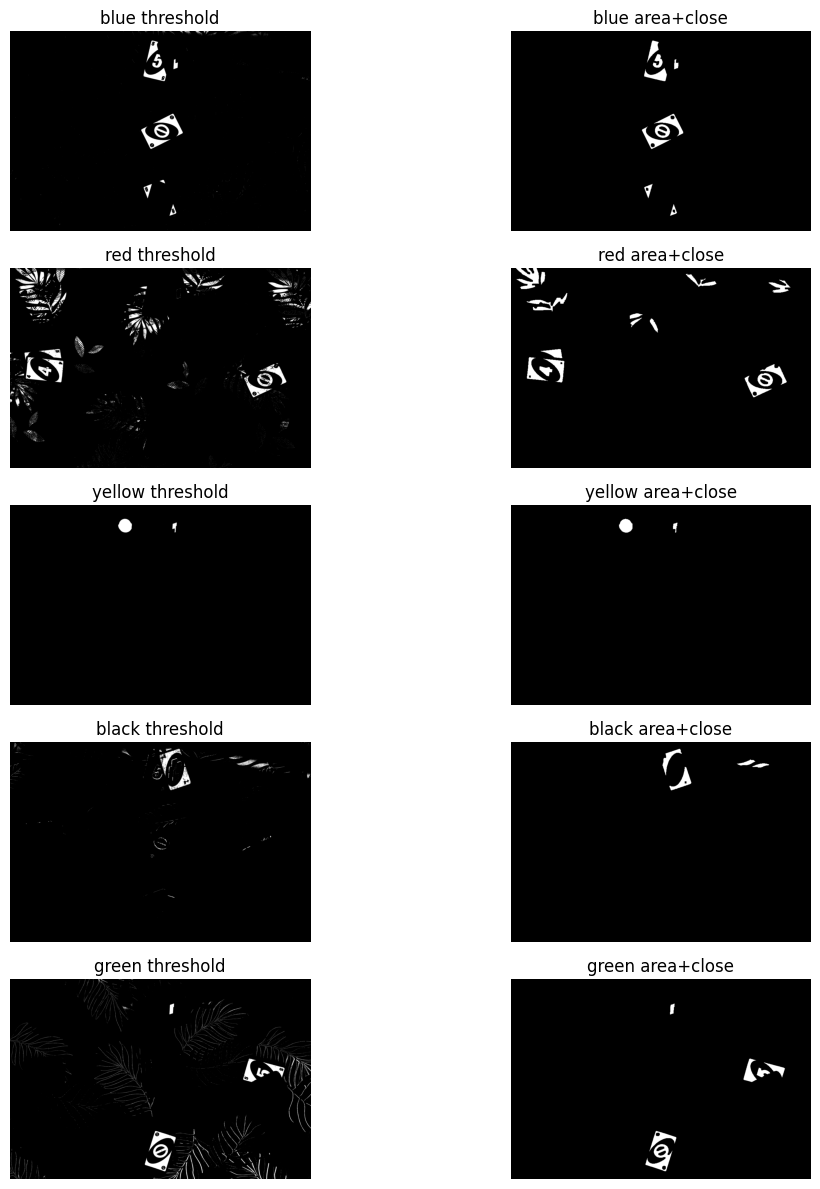

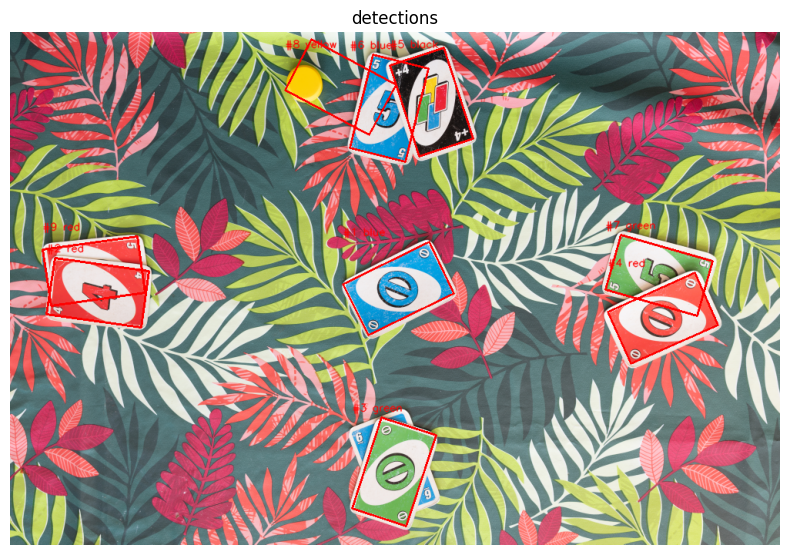

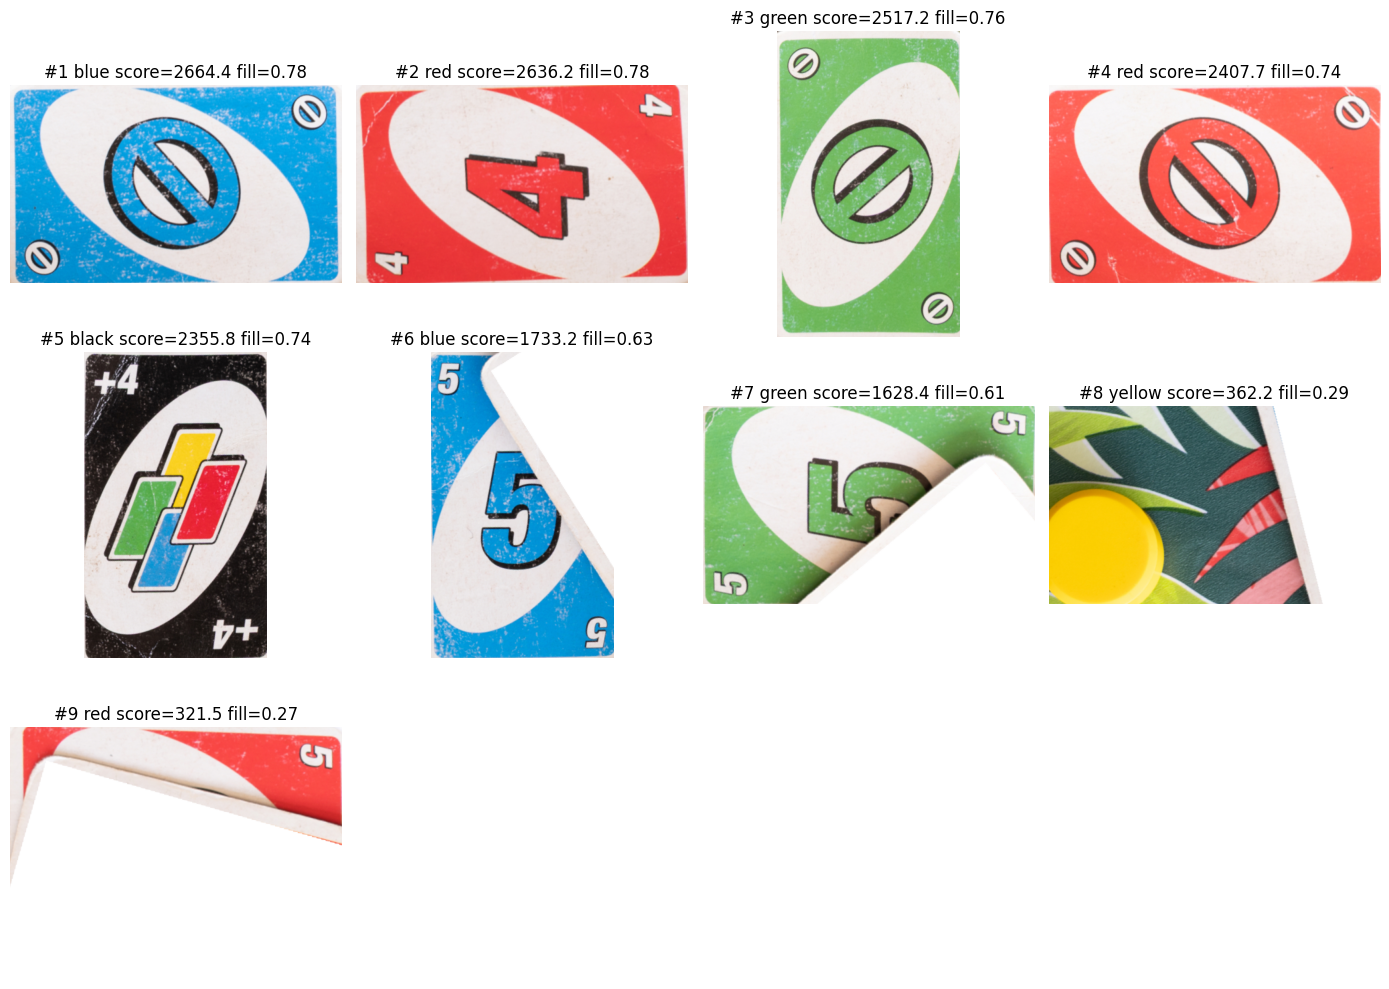

In [6]:
debug_views = []
overlay = cv2.resize(image_rgb, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_AREA).copy()
cleaned_image_bgr = image_bgr.copy()


def collect_candidates(frame_bgr: np.ndarray, capture_debug: bool = False):
    all_candidates = []
    for color in COLORS:
        raw_mask = threshold_color_image(frame_bgr, color_thresholds[color])
        processed_mask = build_threshold_mask(raw_mask, threshold_rectangle_settings)
        small_mask, candidates = detect_rectangles(processed_mask, threshold_rectangle_settings, card_template_mask)
        if capture_debug:
            debug_views.append((f"{color} threshold", raw_mask))
            debug_views.append((f"{color} area+close", small_mask))
            print(f"{color}: {len(candidates)} candidates")
        for candidate in candidates:
            all_candidates.append((color, *candidate))

    unique_candidates = []
    for candidate in sorted(all_candidates, key=lambda item: item[1], reverse=True):
        if all(bbox_iou(candidate[3], kept[3]) < 0.50 for kept in unique_candidates):
            unique_candidates.append(candidate)
    return unique_candidates


detected_cards = []
rank = 1
candidates = collect_candidates(cleaned_image_bgr, capture_debug=True)
while candidates:
    color, score, box, _, _, fill_ratio, placed_template = candidates.pop(0)
    box_int = box.astype(np.int32).reshape(-1, 1, 2)
    x, y, _, _ = cv2.boundingRect(box_int)
    cv2.polylines(overlay, [box_int], True, (255, 0, 0), 2)
    cv2.putText(overlay, f"#{rank} {color}", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1, cv2.LINE_AA)
    try:
        crop = extract_rotated_rectangle(cleaned_image_bgr, box)
    except ValueError as exc:
        print(f"Skipping #{rank}: {exc}")
        continue
    detected_cards.append((f"#{rank} {color} score={score:.1f} fill={fill_ratio:.2f}", cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)))
    paint_detected_rectangle_white(cleaned_image_bgr, box)
    rank += 1
    candidates = collect_candidates(cleaned_image_bgr)

show_images(debug_views, cols=2, figsize=(12, 12))
show_images([("detections", overlay)], cols=1, figsize=(8, 8))
show_images(detected_cards, cols=4, figsize=(14, 10))
